# Decision Tree Classifier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils
from utils import *
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, roc_curve, precision_recall_curve
warnings.filterwarnings(action='ignore')

In [2]:
df = pd.read_csv('../../data/ACME-HappinessSurvey2020_shrunk.csv')
df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [3]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [4]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=seed
)

In [5]:
kfold = KFold(10, shuffle=True, random_state=seed)

# for i, (train, test) in enumerate(kfold.split(X_train, y_train)):
#     print(i)
#     print(train)
#     print(test)

c = [len(test) for (train, test) in kfold.split(X_train, y_train)]

In [6]:
import math
from math import ceil

# maximum max_depth = log2(fold_length) where fold_length = 25 if using 4 fold CV with 100 total observations or in our case fold_length = 10 using 10 fold CV

print(f"Fold length: {c[0]}")

max_max_depth = ceil(np.log2(c[0]))
print(f"Maximum max_depth: {max_max_depth}")

dtc = DecisionTreeClassifier(max_depth=max_max_depth, random_state=seed, criterion='entropy')
dtc.fit(X_train, y_train)

Fold length: 10
Maximum max_depth: 4


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=5249)

In [9]:
return_scores(dtc, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.740000,0.461538
Recall,0.709091,0.285714


[Text(0.4875, 0.9, 'my order was delivered on time <= 4.5\nentropy = 0.993\nsamples = 100\nvalue = [45.0, 55.0]'),
 Text(0.25, 0.7, 'I ordered everything I wanted to order <= 4.5\nentropy = 0.932\nsamples = 46\nvalue = [30, 16]'),
 Text(0.36875, 0.8, 'True  '),
 Text(0.2, 0.5, 'the app makes ordering easy <= 3.5\nentropy = 0.959\nsamples = 42\nvalue = [26, 16]'),
 Text(0.1, 0.3, 'I paid good price for my order <= 3.5\nentropy = 0.65\nsamples = 12\nvalue = [10, 2]'),
 Text(0.05, 0.1, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.15, 0.1, 'entropy = 0.863\nsamples = 7\nvalue = [5, 2]'),
 Text(0.3, 0.3, 'I am satisfied with my courier <= 4.5\nentropy = 0.997\nsamples = 30\nvalue = [16, 14]'),
 Text(0.25, 0.1, 'entropy = 0.992\nsamples = 29\nvalue = [16, 13]'),
 Text(0.35, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.725, 0.7, 'I ordered everything I wanted to order <= 3.5\nentropy = 0.852\nsamples = 54\

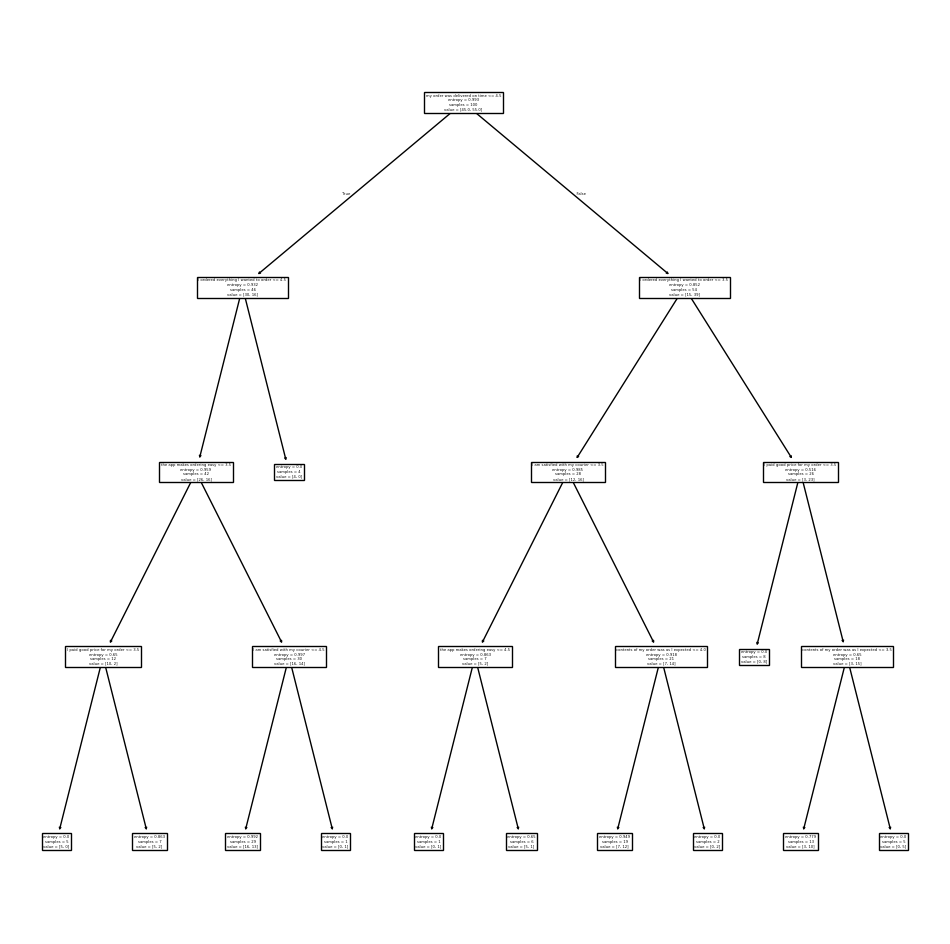

In [10]:
ax = plt.subplots(figsize=(12, 12))[1]

plot_tree(dtc,
          feature_names=X_train.columns,
          ax=ax
          )

In [11]:
print(export_text(dtc,
                  feature_names=X_train.columns,
                  show_weights=True
                  ))

|--- my order was delivered on time <= 4.50
|   |--- I ordered everything I wanted to order <= 4.50
|   |   |--- the app makes ordering easy <= 3.50
|   |   |   |--- I paid good price for my order <= 3.50
|   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |--- I paid good price for my order >  3.50
|   |   |   |   |--- weights: [5.00, 2.00] class: 0
|   |   |--- the app makes ordering easy >  3.50
|   |   |   |--- I am satisfied with my courier <= 4.50
|   |   |   |   |--- weights: [16.00, 13.00] class: 0
|   |   |   |--- I am satisfied with my courier >  4.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |--- I ordered everything I wanted to order >  4.50
|   |   |--- weights: [4.00, 0.00] class: 0
|--- my order was delivered on time >  4.50
|   |--- I ordered everything I wanted to order <= 3.50
|   |   |--- I am satisfied with my courier <= 3.50
|   |   |   |--- the app makes ordering easy <= 4.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |  

In [12]:
importance_df = pd.DataFrame({
    'Importance': dtc.feature_importances_
}, index=X_train.columns).sort_values(by='Importance', ascending=True)

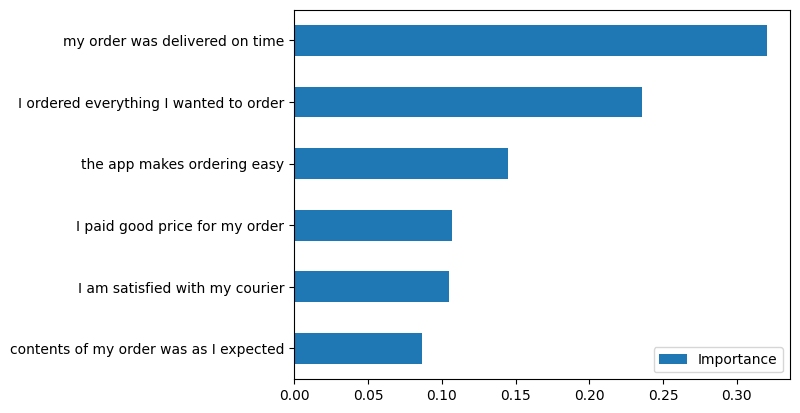

In [13]:
importance_df.plot(kind='barh')
plt.show()

In [14]:
ccp_path = dtc.cost_complexity_pruning_path(X_train, y_train)

In [15]:
ccp_path

{'ccp_alphas': array([0.        , 0.01128016, 0.01244624, 0.01568856, 0.01714217,
        0.01758425, 0.02141709, 0.02260331, 0.02561881, 0.02611233,
        0.05028872, 0.10370434]),
 'impurities': array([0.66888847, 0.68016864, 0.69261488, 0.70830344, 0.7254456 ,
        0.74302985, 0.76444695, 0.78705026, 0.81266907, 0.8387814 ,
        0.88907012, 0.99277445])}

In [16]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=seed)

grid = RandomizedSearchCV(dtc,
        {'ccp_alpha': ccp_path.ccp_alphas},
        refit=False,
        cv=kfold,
        scoring=['accuracy', 'recall'],
        random_state=seed,
        return_train_score=True
        )
grid.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
                   estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=4,
                                                    random_state=5249),
                   param_distributions={'ccp_alpha': array([0.        , 0.01128016, 0.01244624, 0.01568856, 0.01714217,
       0.01758425, 0.02141709, 0.02260331, 0.02561881, 0.02611233,
       0.05028872, 0.10370434])},
                   random_state=5249, refit=False, return_train_score=True,
                   scoring=['accuracy', 'recall'])

In [17]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.004313,0.004257,0.005864,0.003852,0.000000,{'ccp_alpha': 0.0},0.4,0.5,0.4,0.8,...,0.739130,0.679245,0.58,0.74,0.74,0.980392,0.755102,0.877551,0.769771,0.111049
1,0.009877,0.009273,0.009989,0.009636,0.012446,{'ccp_alpha': 0.012446242227732579},0.6,0.5,0.5,0.8,...,0.782609,0.679245,0.56,0.72,0.74,0.980392,0.755102,0.877551,0.741548,0.115128
2,0.005596,0.005221,0.016056,0.028620,0.011280,{'ccp_alpha': 0.011280164365837064},0.4,0.5,0.5,0.8,...,0.782609,0.679245,0.58,0.74,0.74,0.980392,0.755102,0.877551,0.774119,0.110615
3,0.008391,0.009007,0.017279,0.021014,0.025619,{'ccp_alpha': 0.025618810658101898},0.6,0.5,0.5,0.7,...,0.717391,0.660377,0.70,0.72,0.72,0.960784,0.734694,0.877551,0.745262,0.093973
4,0.008583,0.014337,0.009199,0.009506,0.015689,{'ccp_alpha': 0.015688557048732663},0.6,0.5,0.5,0.8,...,0.782609,0.660377,0.56,0.72,0.74,0.980392,0.734694,0.877551,0.735537,0.116863


In [18]:
grid_df.sort_values(by='param_ccp_alpha', ascending=True, inplace=True)

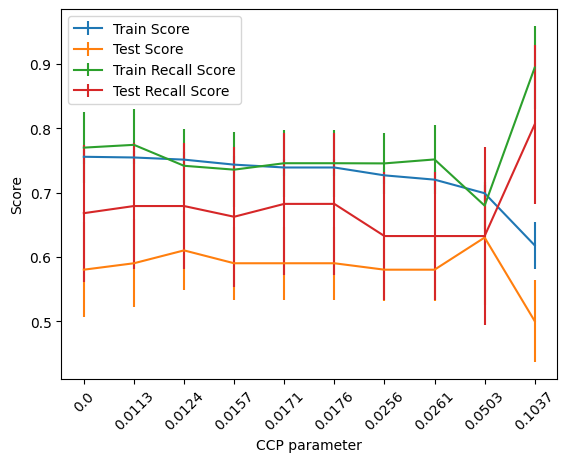

In [19]:
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_ccp_alpha'])), round(grid_df['param_ccp_alpha'], 4), rotation=45)
plt.xlabel('CCP parameter')
plt.ylabel('Score')
plt.legend()
plt.show()

In [36]:
.0503+((.1037-.0503)/2)

0.077

[Text(0.5, 0.75, 'my order was delivered on time <= 4.5\nentropy = 0.993\nsamples = 100\nvalue = [45.0, 55.0]'),
 Text(0.25, 0.25, 'entropy = 0.932\nsamples = 46\nvalue = [30, 16]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.852\nsamples = 54\nvalue = [15, 39]'),
 Text(0.625, 0.5, '  False')]

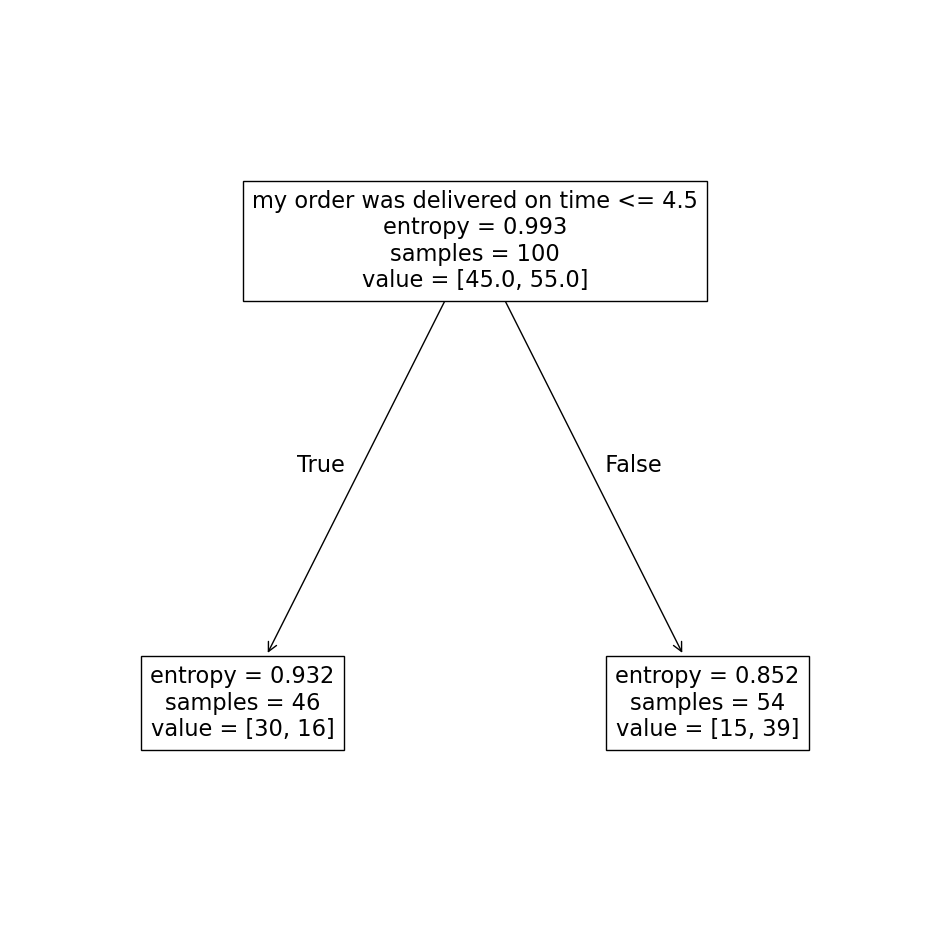

In [20]:
ax = plt.subplots(figsize=(12, 12))[1]

best_ = DecisionTreeClassifier(
    random_state=seed,
    criterion='entropy',
    ccp_alpha=.0770,
    max_depth=4
    ).fit(X_train, y_train)

plot_tree(best_,
feature_names=X_train.columns,
ax=ax)

In [21]:
print(export_text(best_,
                    feature_names=X_train.columns,
                    show_weights=True))

|--- my order was delivered on time <= 4.50
|   |--- weights: [30.00, 16.00] class: 0
|--- my order was delivered on time >  4.50
|   |--- weights: [15.00, 39.00] class: 1



In [23]:
return_scores(best_, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.690000,0.500000
Recall,0.709091,0.428571


In [24]:
best_coef_df = pd.DataFrame({
    'Importance': best_.feature_importances_
}, index=X_train.columns).sort_values('Importance', ascending=True)

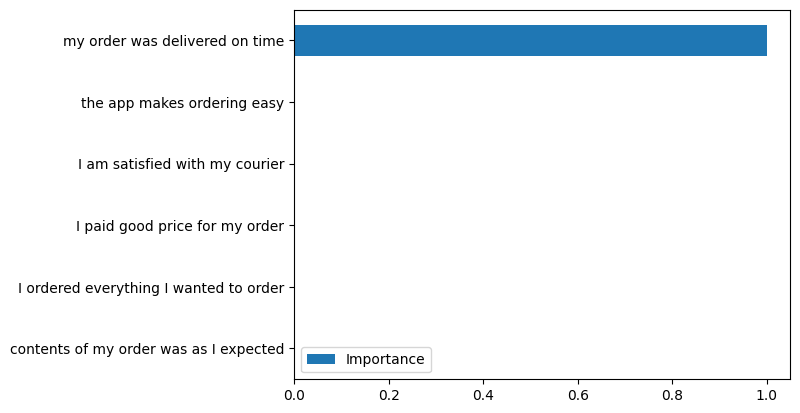

In [25]:
best_coef_df.plot(kind='barh')
plt.show()

### Random Forest and Bagging

This section utilizes ensemble methods whereby using mulitple trees to agregate a decision in the splitting of node leaves. The main different between the two methods of this section are the max_features used. In the case of Bagging the max_features will equal the number of predictors form the dataset.

A Random Forest model will be utilized also but will only utilize the square root of the number of predictors (√6 = 2.45). We will try 2 and 3 for the bagging method.

In [26]:
# Bagging

rf = RandomForestClassifier(max_features=X_train.shape[1],
                            max_depth=4,
                            random_state=seed,
                            criterion='entropy')
rf

RandomForestClassifier(criterion='entropy', max_depth=4, max_features=6,
                       random_state=5249)

In [27]:
rf.fit(X_train, y_train)

return_scores(rf, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.810000,0.538462
Recall,0.781818,0.357143


In [28]:
rf_params = {
    'n_estimators': np.arange(1, 5000, 125)
}

rf_grid = RandomizedSearchCV(rf,
        rf_params,
        refit=False,
        cv=kfold,
        scoring=['accuracy', 'recall'],
        return_train_score=True,
        random_state=seed
        )

rf_grid.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
                   estimator=RandomForestClassifier(criterion='entropy',
                                                    max_depth=4, max_features=6,
                                                    random_state=5249),
                   param_distributions={'n_estimators': array([   1,  126,  251,  376,  501,  626,  751,  876, 1001, 1126, 1251,
       1376, 1501, 1626, 1751, 1876, 2001, 2126, 2251, 2376, 2501, 2626,
       2751, 2876, 3001, 3126, 3251, 3376, 3501, 3626, 3751, 3876, 4001,
       4126, 4251, 4376, 4501, 4626, 4751, 4876])},
                   random_state=5249, refit=False, return_train_score=True,
                   scoring=['accuracy', 'recall'])

In [29]:
rf_df = pd.DataFrame(rf_grid.cv_results_)
rf_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,7.095572,2.150193,0.407887,0.159844,2126,{'n_estimators': 2126},0.6,0.5,0.5,0.8,...,0.804348,0.849057,0.86,0.88,0.82,0.901961,0.836735,0.897959,0.854096,0.030309
1,0.352655,0.073131,0.026013,0.009655,126,{'n_estimators': 126},0.6,0.5,0.5,0.7,...,0.804348,0.905660,0.84,0.88,0.80,0.882353,0.836735,0.938776,0.853753,0.043654
2,8.261852,0.844403,0.546117,0.125048,3251,{'n_estimators': 3251},0.6,0.5,0.5,0.8,...,0.804348,0.886792,0.86,0.88,0.82,0.901961,0.857143,0.897959,0.861994,0.031227
3,2.371506,0.102154,0.142840,0.028976,1126,{'n_estimators': 1126},0.6,0.5,0.5,0.8,...,0.804348,0.905660,0.86,0.88,0.82,0.901961,0.857143,0.897959,0.859756,0.035118
4,2.612109,0.552381,0.150125,0.038273,1001,{'n_estimators': 1001},0.6,0.5,0.5,0.8,...,0.804348,0.886792,0.86,0.88,0.82,0.901961,0.857143,0.897959,0.859953,0.033402


In [30]:
rf_df.sort_values(by='param_n_estimators', ascending=True, inplace=True)

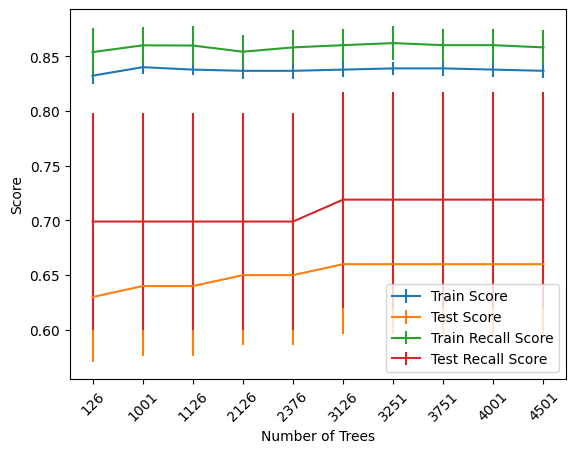

In [31]:
plt.errorbar(
    np.arange(len(rf_df['param_n_estimators'])),
    rf_df['mean_train_accuracy'],
    yerr=rf_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(rf_df['param_n_estimators'])),
    rf_df['mean_test_accuracy'],
    yerr=rf_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(rf_df['param_n_estimators'])),
    rf_df['mean_train_recall'],
    yerr=rf_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(rf_df['param_n_estimators'])),
    rf_df['mean_test_recall'],
    yerr=rf_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(rf_df['param_n_estimators'])), round(rf_df['param_n_estimators'], 4), rotation=45)
plt.xlabel('Number of Trees')
plt.ylabel('Score')
plt.legend()
plt.show()

In [33]:
rf_tuned = RandomForestClassifier(max_features=X_train.shape[1],
                                  max_depth=4,
                                  n_estimators=3126,
                                  random_state=seed).fit(X_train, y_train)

return_scores(rf_tuned, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.830000,0.576923
Recall,0.854545,0.428571


In [34]:
# Random Forest

rf_2 = RandomForestClassifier(max_features=2,
                              max_depth=4,
                              random_state=seed,
                              bootstrap=False,
                              criterion='entropy')

In [35]:
rf_2.fit(X_train, y_train)

return_scores(rf_2, X_train, X_test, y_train, y_test)

,Train Scores,Test Scores
Accuracy,0.770000,0.500000
Recall,0.745455,0.357143


In [36]:
rf_2_params = {
    # 'max_features': [2,3],
    'n_estimators': np.arange(1, 5000, 125)
}

rf_2_grid = RandomizedSearchCV(rf_2,
        rf_2_params,
        refit=False,
        cv=kfold,
        scoring=['accuracy', 'recall'],
        return_train_score=True,
        random_state=seed
        )

rf_2_grid.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
                   estimator=RandomForestClassifier(bootstrap=False,
                                                    criterion='entropy',
                                                    max_depth=4, max_features=2,
                                                    random_state=5249),
                   param_distributions={'n_estimators': array([   1,  126,  251,  376,  501,  626,  751,  876, 1001, 1126, 1251,
       1376, 1501, 1626, 1751, 1876, 2001, 2126, 2251, 2376, 2501, 2626,
       2751, 2876, 3001, 3126, 3251, 3376, 3501, 3626, 3751, 3876, 4001,
       4126, 4251, 4376, 4501, 4626, 4751, 4876])},
                   random_state=5249, refit=False, return_train_score=True,
                   scoring=['accuracy', 'recall'])

In [37]:
rf_2_df = pd.DataFrame(rf_2_grid.cv_results_)
rf_2_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,1.612428,0.343234,0.110355,0.025184,2126,{'n_estimators': 2126},0.6,0.5,0.5,0.8,...,0.782609,0.849057,0.68,0.76,0.76,0.921569,0.816327,0.897959,0.805510,0.066883
1,0.080561,0.006470,0.008287,0.000926,126,{'n_estimators': 126},0.6,0.5,0.5,0.8,...,0.673913,0.849057,0.68,0.84,0.76,0.921569,0.816327,0.897959,0.802641,0.077822
2,2.155493,0.270534,0.169526,0.081178,3251,{'n_estimators': 3251},0.6,0.5,0.5,0.8,...,0.782609,0.849057,0.68,0.76,0.76,0.921569,0.816327,0.897959,0.803427,0.067602
3,0.669069,0.002540,0.048784,0.000225,1126,{'n_estimators': 1126},0.6,0.5,0.5,0.8,...,0.760870,0.849057,0.68,0.76,0.76,0.921569,0.816327,0.897959,0.803337,0.067937
4,0.594262,0.001306,0.043932,0.000882,1001,{'n_estimators': 1001},0.6,0.5,0.5,0.8,...,0.760870,0.849057,0.68,0.76,0.76,0.921569,0.816327,0.897959,0.803337,0.067937


In [38]:
rf_2_df.sort_values(by=['param_n_estimators'], ascending=True, inplace=True)

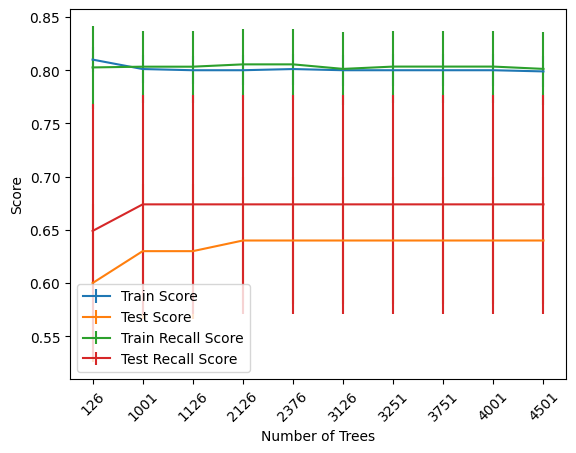

In [39]:
plt.errorbar(
    np.arange(len(rf_2_df['param_n_estimators'])),
    rf_2_df['mean_train_accuracy'],
    yerr=rf_2_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(rf_2_df['param_n_estimators'])),
    rf_2_df['mean_test_accuracy'],
    yerr=rf_2_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(rf_2_df['param_n_estimators'])),
    rf_2_df['mean_train_recall'],
    yerr=rf_2_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(rf_2_df['param_n_estimators'])),
    rf_2_df['mean_test_recall'],
    yerr=rf_2_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(rf_2_df['param_n_estimators'])), round(rf_2_df['param_n_estimators'], 4), rotation=45)
plt.xlabel('Number of Trees')
plt.ylabel('Score')
plt.legend()
plt.show()

In [40]:
rf_2_tuned = RandomForestClassifier(
    max_features=2,
    n_estimators=2100,
    max_depth=4,
    random_state=seed,
    bootstrap=False,
    criterion='entropy')

In [41]:
rf_2_tuned.fit(X_train, y_train)

return_scores(rf_2_tuned,
              X_train,
              X_test,
              y_train,
              y_test)

,Train Scores,Test Scores
Accuracy,0.760000,0.500000
Recall,0.745455,0.357143


In [42]:
## for a test split of 20% the rf_tuned model worked best. With 50% it was the decision tree

best_coef_df = pd.DataFrame({
    'Importance': rf_tuned.feature_importances_
}, index=X_train.columns).sort_values('Importance', ascending=True)

best_coef_df

,Importance
I paid good price for my order,0.100725
contents of my order was as I expected,0.101860
the app makes ordering easy,0.131202
I ordered everything I wanted to order,0.173795
I am satisfied with my courier,0.203205
my order was delivered on time,0.289214


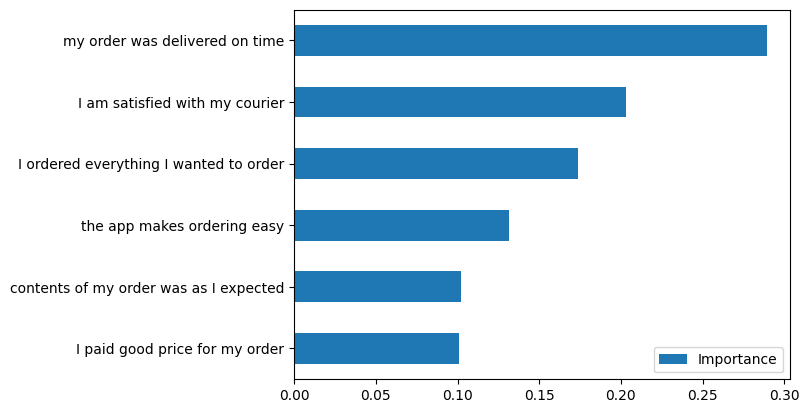

In [43]:
best_coef_df.plot(kind='barh')
plt.show()

In [74]:
import pathlib

path = pathlib.Path('../../feature importances/bagging_features.csv')

if path.exists() != True:
    best_coef_df.to_csv(path)

Experimenting with different tree based models we can see that using a bagging method via the RandomForest model performed best, but still did not outperform the logistic regression model.

The RandomForest model alone does not perform due to the fact that the number of predictors is small (6) and that not many of the predictors are correlated to each other. (Intro to Statistical Learning p.347)